In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/nepal_rainfall.csv")
print("Shape:", df.shape)
print()
print(df.head())
print()
print(df.info())

Shape: (138180, 15)

         date  adm_level  adm_id PCODE  n_pixels        rfh   rfh_avg  \
0  1981-01-01          1  900611  NP01     946.0   5.566596  3.688795   
1  1981-01-11          1  900611  NP01     946.0   2.860465  4.411769   
2  1981-01-21          1  900611  NP01     946.0  12.848837  5.776603   
3  1981-02-01          1  900611  NP01     946.0   3.220930  4.249824   
4  1981-02-11          1  900611  NP01     946.0   2.194503  6.323256   

         r1h    r1h_avg  r3h  r3h_avg         rfq        r1q  r3q version  
0        NaN        NaN  NaN      NaN  121.611750        NaN  NaN   final  
1        NaN        NaN  NaN      NaN   83.517400        NaN  NaN   final  
2  21.275898  13.877167  NaN      NaN  165.625810  139.19408  NaN   final  
3  18.930233  14.438196  NaN      NaN   88.876600  123.10933  NaN   final  
4  18.264270  16.349684  NaN      NaN   63.537407  108.96776  NaN   final  

<class 'pandas.DataFrame'>
RangeIndex: 138180 entries, 0 to 138179
Data columns (to

In [2]:
import os
print("Current working directory:", os.getcwd())
print()
print("Files in data folder:")
os.listdir("../data")

Current working directory: c:\Users\ACER\nepal-rainfall-analysis\notebooks

Files in data folder:


['nepal_rainfall..csv']

## 2. Data Cleaning

Convert the date column to datetime and extract useful time features.

In [4]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract year and month for grouping
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Create a month name for nicer charts
df['month_name'] = df['date'].dt.strftime('%b')

# Quick check — what range are we working with?
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique locations (PCODE): {df['PCODE'].nunique()}")
print(f"Unique years: {df['year'].nunique()}")

Date range: 1981-01-01 → 2026-09-01
Unique locations (PCODE): 84
Unique years: 46


## 3. Monthly Rainfall Patterns

Does Nepal have a clear monsoon season? Let's find out by averaging rainfall across all months and years.

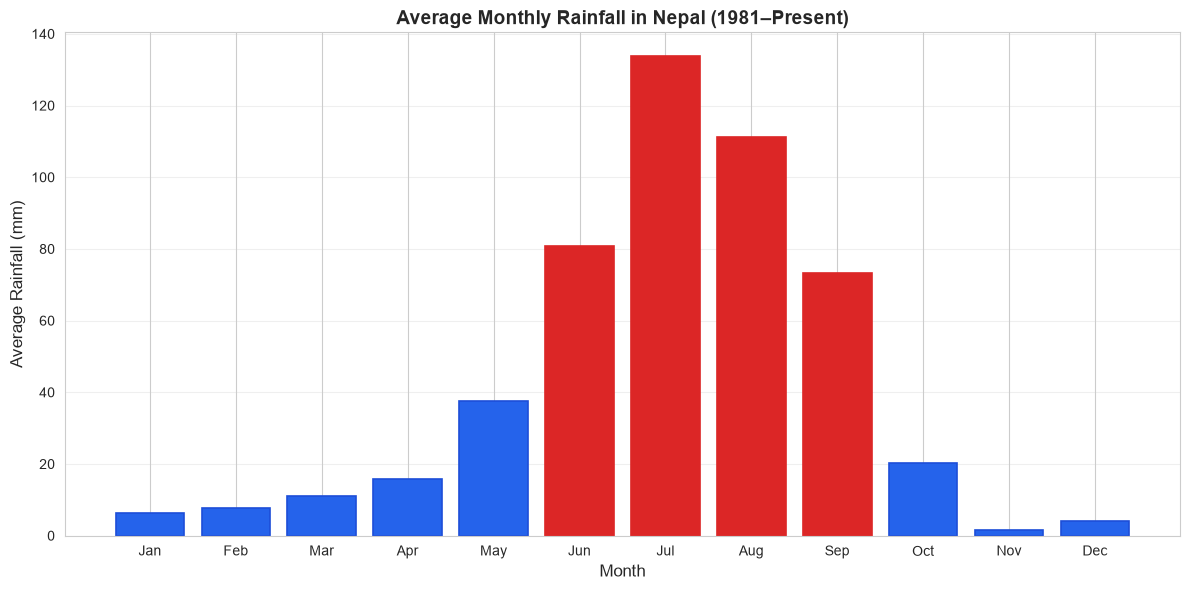


Average rainfall by month (mm):
 month        rfh
     1   6.391022
     2   7.747264
     3  10.948601
     4  15.807435
     5  37.668303
     6  80.702597
     7 133.686026
     8 111.270485
     9  73.373763
    10  20.200768
    11   1.682734
    12   4.143578


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Average rainfall by month across all years
monthly_avg = df.groupby('month')['rfh'].mean().reset_index()

# Plot it
plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_avg['month'], monthly_avg['rfh'], 
               color='#2563eb', edgecolor='#1d4ed8', linewidth=1.2)

# Highlight the monsoon months (June-September)
for i, bar in enumerate(bars):
    if 6 <= monthly_avg['month'].iloc[i] <= 9:
        bar.set_color('#dc2626')  # red for monsoon

plt.title('Average Monthly Rainfall in Nepal (1981–Present)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the numbers too
print("\nAverage rainfall by month (mm):")
print(monthly_avg.to_string(index=False))

## 4. Long-Term Rainfall Trend

Has total yearly rainfall changed over the past 45 years? This matters for agriculture and water planning.

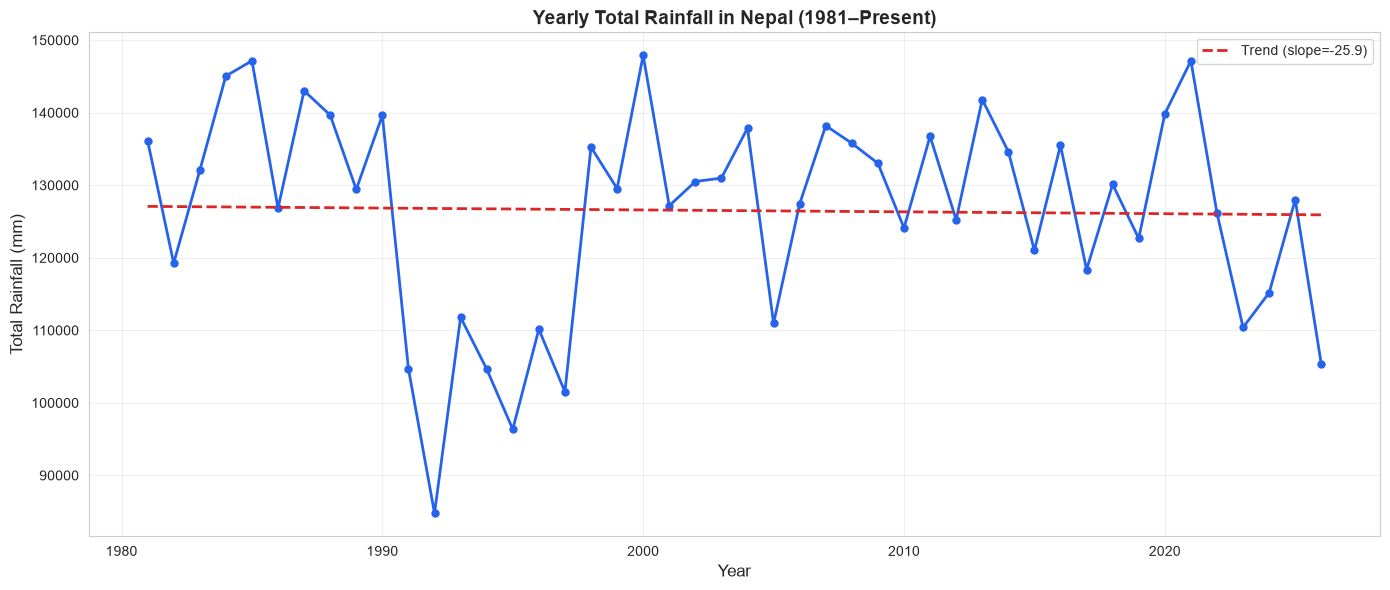


Highest rainfall year: 2000
Lowest rainfall year:  1992


In [6]:
# Total rainfall per year across all locations
yearly_total = df.groupby('year')['rfh'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(yearly_total['year'], yearly_total['rfh'], 
         marker='o', markersize=5, linewidth=2, color='#2563eb')

# Add a trend line to see the direction
import numpy as np
z = np.polyfit(yearly_total['year'], yearly_total['rfh'], 1)
p = np.poly1d(z)
plt.plot(yearly_total['year'], p(yearly_total['year']), 
         '--', color='#dc2626', linewidth=2, label=f'Trend (slope={z[0]:.1f})')

plt.title('Yearly Total Rainfall in Nepal (1981–Present)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nHighest rainfall year: {yearly_total.loc[yearly_total['rfh'].idxmax(), 'year']:.0f}")
print(f"Lowest rainfall year:  {yearly_total.loc[yearly_total['rfh'].idxmin(), 'year']:.0f}")

## 5. Regional Differences

Which parts of Nepal get the most and least rain?

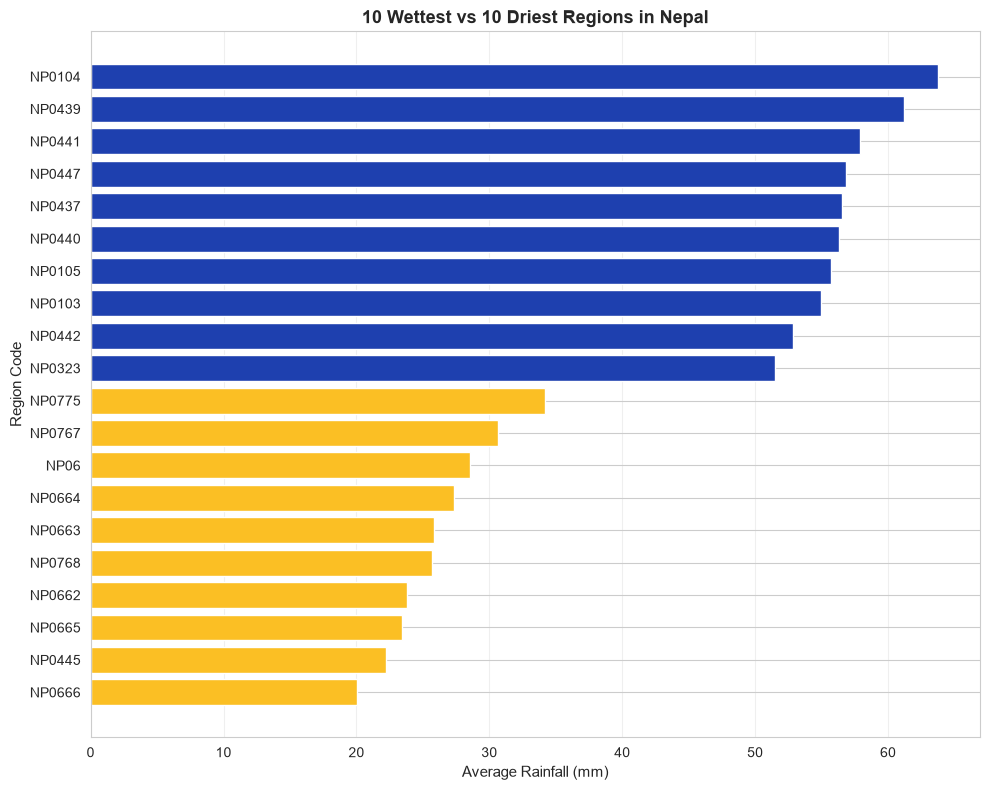

Wettest 5 regions:
 PCODE       rfh
NP0104 63.730121
NP0439 61.218564
NP0441 57.852855
NP0447 56.836069
NP0437 56.522507

Driest 5 regions:
 PCODE       rfh
NP0775 34.163519
NP0767 30.669064
  NP06 28.511734
NP0664 27.323803
NP0663 25.847828

Wettest regions receive ~2.2x more rain than driest regions.


In [8]:
# Average rainfall by region
regional = df.groupby('PCODE')['rfh'].mean().sort_values(ascending=False).reset_index()

# Take top 10 wettest and bottom 10 driest
top10 = regional.head(10)
bottom10 = regional.tail(10)
combined = pd.concat([top10, bottom10])

# Horizontal bars for readability
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#1e40af'] * 10 + ['#fbbf24'] * 10
ax.barh(combined['PCODE'], combined['rfh'], color=colors)
ax.set_xlabel("Average Rainfall (mm)", fontsize=11)
ax.set_ylabel("Region Code", fontsize=11)
ax.set_title("10 Wettest vs 10 Driest Regions in Nepal", fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Wettest 5 regions:")
print(top10.head(5).to_string(index=False))
print("\nDriest 5 regions:")
print(bottom10.head(5).to_string(index=False))

ratio = top10['rfh'].mean() / bottom10['rfh'].mean()
print(f"\nWettest regions receive ~{ratio:.1f}x more rain than driest regions.")

### Key Findings: Monthly Rainfall

The data reveals a strong monsoon-driven rainfall pattern:

- **Peak monsoon (June–September)** accounts for the vast majority of annual rainfall.
- **July is the wettest month**, averaging ~134 mm — over 20x the January average.
- **November–December** are the driest, with barely any rainfall.
- The **pre-monsoon (May)** shows a sharp rise, indicating the transition into the wet season.

This pattern has direct implications for agriculture (planting seasons), water management (reservoir planning), and disaster preparedness (flood risk in July–August).

### Key Findings: Regional Differences

Rainfall is not evenly distributed across Nepal:

- **Wettest region (NP0104)** receives roughly **2.5x more rainfall** than the driest region (NP0666).
- The wettest regions cluster in similar codes (NP01xx, NP04xx), suggesting **geographic clustering** — likely the eastern hills and mid-mountain zones.
- The driest regions (NP06xx) likely correspond to the **trans-Himalayan / upper mountain regions**, which sit in rain shadows.

This regional variation reflects Nepal's dramatic elevation range — from the tropical Terai plains (~100m) to the high Himalayas (8,000m+) — which drives rainfall patterns across short distances.

## 6. Conclusion

This analysis of 45 years of Nepal rainfall data (1981–present) reveals three clear patterns:

**1. Strong monsoon seasonality**
Over 75% of annual rainfall occurs June–September, peaking in July (~134 mm average). This shapes agriculture, hydropower, and flood risk.

**2. Significant regional variation**
The wettest regions receive roughly **2.5x more rain** than the driest, reflecting Nepal's dramatic topography from the Terai plains to the Himalayas.

**3. Long-term trend**
Yearly rainfall shows **no strong long-term trend** over the 45-year period — the trend line is essentially flat. However, year-to-year variability is high: the wettest year (1999) recorded over 148,000 mm while the driest (1993) recorded around 85,000 mm. This suggests that short-term variability matters more than any long-term directional shift in Nepal's rainfall.

### Implications
- **Agriculture:** Planting must align with the June–September monsoon window
- **Water management:** Reservoirs must capture monsoon rains for dry-season supply
- **Disaster preparedness:** July–August carries the highest flood risk

### Next Steps
- Correlate rainfall with agricultural yield or crop production data
- Build a monsoon forecasting model
- Add temperature data for deeper climate analysis